# SULO Pizza Tutorial — Information Entities

# Learning objectives

* Understand what an `InformationObject` is and how it differs from a `SpatialObject`
* Create named individuals (instances) in OWL
* Use annotation properties to document individuals
* Assert individual equality (`SameAs`) and inequality (`AllDifferent`)
* Understand why the Open World Assumption requires explicit inequality assertions

# Information Entities

So far we have modelled *things that exist in the world*: pizzas, ingredients, and the processes that create and transform them. But the world also contains a second, fundamentally different kind of entity — **information objects**: things whose primary function is to carry meaning *about* something else.

When you order a pizza, the restaurant creates a **pizza order** — a record of what was requested. When you pay, you receive a **receipt** — a document recording the transaction. Neither of these is a spatial object in the sense that a pizza is: a receipt has no flavour, no crust, no toppings. It exists to *represent* information.

SULO captures this distinction with the `sulo:InformationObject` class. An information object's identity is defined by its content and representational role, not by its physical substrate. A printed receipt and a digital PDF of the same receipt are two *representations* of the same information.

In this notebook we will:
1. Define `PizzaOrder` and `PizzaReceipt` as kinds of `InformationObject`
2. Create named **individuals** — specific instances of these classes
3. Use **data properties** to attach literal values (order IDs, amounts) to individuals
4. Explore what it means for two individuals to be the *same* or *different* in OWL

In [1]:


import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break
    
from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()  # RDF/XML
se = get_ontology("dist/sulo-ext.owl").load()
pizza = get_ontology("dist/pizza-03.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(se)

## Defining Information Entity Classes

We first introduce two subclasses of `sulo:InformationObject`:

- `PizzaOrder` — an information object encoding a customer's request
- `PizzaReceipt` — an information object issued after payment

We use SULO's `refersTo` object property to link an information object to the entity it represents, and two data properties for literal attributes.

In [2]:
with pizza:
    class PizzaOrder(sulo.InformationObject):
        """An information entity encoding a customer request to prepare a pizza."""
        pass

    class PizzaReceipt(sulo.InformationObject):
        """An information entity issued to a customer recording the details and cost of a pizza transaction."""
        pass

    class OnlineOrder(PizzaOrder):
        """A pizza order placed via an online ordering platform."""
        pass

    class PhoneOrder(PizzaOrder):
        """A pizza order placed by telephone."""
        pass

    # Disjointness: the same order cannot be both online and by phone
    AllDisjoint([OnlineOrder, PhoneOrder])

    class OrderIdentifier(sulo.InformationObject):
        """A unique string identifier for a pizza order."""
        pass

    class OrderAmount(sulo.InformationObject):
        """The total monetary amount on a receipt, in a particular currency."""
        pass

## Creating Individuals

In OWL, **individuals** (also called *instances* or *ABox assertions*) are named entities that belong to one or more classes. Unlike classes — which describe sets — an individual represents a specific, uniquely identified thing.

In owlready2, an individual is created by calling the class like a constructor:

```python
order_001 = PizzaOrder("order_001")
```

The string `"order_001"` becomes the local name in the ontology IRI. Annotation properties (`label`, `comment`) are inherited from `rdfs:label` and `rdfs:comment`.

In [3]:
with pizza:
    # Two specific pizza orders
    order_001 = PizzaOrder("order_001")
    order_001.label   = ["Pizza Order #001"]
    order_001.comment = ["Order for a TraditionalFourCheesePizza, placed at the counter."]
    order_001.hasFeature = [OrderIdentifier("ORD-001")]

    order_002 = OnlineOrder("order_002")
    order_002.label   = ["Pizza Order #002 (online)"]
    order_002.hasFeature = [OrderIdentifier("ORD-002")]

    # A receipt linked to the first order
    receipt_001 = PizzaReceipt("receipt_001")
    receipt_001.label        = ["Receipt #001"]
    receipt_001.hasFeature = [OrderAmount(12.50)]
    receipt_001.refersTo      = [order_001]

print("order_001 identifier  :", order_001.hasFeature[0])
print("receipt_001 amount    :", receipt_001.hasFeature[0])
print("receipt_001 refersTo  :", receipt_001.refersTo)
print("order_002 types       :", order_002.is_a)

order_001 identifier  : pizza-03.ORD-001
receipt_001 amount    : pizza-03.12.5
receipt_001 refersTo  : [pizza-03.order_001]
order_002 types       : [pizza-03.OnlineOrder]


## The Open World Assumption and Individual Identity

In classical database thinking, the *Unique Name Assumption* (UNA) holds: two different names always refer to two different things. OWL makes **no** such assumption. Under the Open World Assumption, `order_001` and `order_002` might refer to the same pizza order unless we explicitly say otherwise.

This matters for reasoning: if the reasoner is allowed to consider `order_001` and `order_002` as the same individual, it may merge their properties in unexpected ways.

To assert that a set of individuals are *pairwise distinct*, use `AllDifferent`.

In [4]:
with pizza:
    AllDifferent([order_001, order_002, receipt_001])

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


## Individual Equality — `SameAs`

The flip side of `AllDifferent` is asserting that two names *do* refer to the same individual. This is expressed with `owl:sameAs`, represented in owlready2 by assigning to `equivalent_to` on an individual.

For example, a legacy system might record order ORD-001 under an old identifier. We can assert the two records are the same real-world order.

In [5]:
with pizza:
    # A duplicate entry for order_001 imported from a legacy system
    order_001_legacy = PizzaOrder("order_001_legacy")
    order_001_legacy.label            = ["ORD-001 (legacy system)"]
    order_001_legacy.hasFeature  = [OrderAmount("LEGACY-001")]

    # Assert they refer to the same individual (owl:sameAs)
    order_001.equivalent_to.append(order_001_legacy)

result = safe_call_reasoner(pizza)
print("Consistent after sameAs assertion:", result["ok"])
# After reasoning, the two names become aliases for one individual
print("order_001 equivalent_to:", order_001.equivalent_to)

Consistent after sameAs assertion: True
order_001 equivalent_to: [pizza-03.order_001_legacy]


## Defined Classes for Information Entities

Just as we defined `SpicyPizza` in terms of quality restrictions, we can define information-entity classes in terms of what they are *about*. An `OrderForSpicyPizza` is a `PizzaOrder` that `isAbout` some `SpicyPizza`.

In [6]:
with pizza:
    class OrderForFourCheesePizza(PizzaOrder):
        """A pizza order that is about a FourCheesePizza."""
        equivalent_to = [PizzaOrder & sulo.refersTo.some(pizza.FourCheesePizza)]

    class OrderForSpicyPizza(PizzaOrder):
        """A pizza order that is about a SpicyPizza."""
        equivalent_to = [PizzaOrder & sulo.refersTo.some(pizza.SpicyPizza)]

# Classify: order_001 is about a TraditionalFourCheesePizza
# (which the reasoner knows is a subtype of FourCheesePizza)
with pizza:
    my_pizza = pizza.TraditionalFourCheesePizza("quattro_formaggi_001")
    order_001.refersTo.append(my_pizza)

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
# Check inferred types of order_001
print("order_001 inferred types:", [t for t in order_001.is_a if hasattr(t, 'name')])

Consistent: True
order_001 inferred types: [pizza-03.OrderForFourCheesePizza]


Saved pizza-04.owl


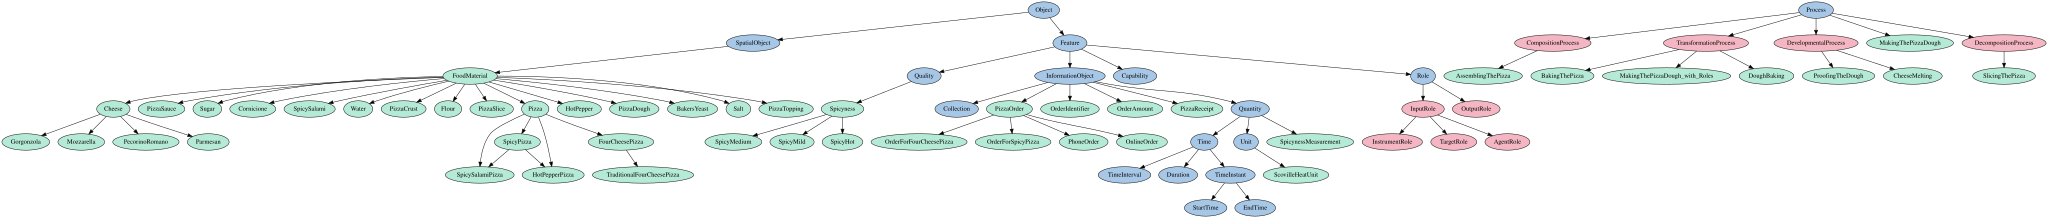

In [7]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-04.owl", format="rdfxml")
print("Saved pizza-04.owl")
display(get_color_tree([sulo, se, pizza]))

---

## Exercises

### Exercise 1 — Model a `DeliveryAddress`
Define a `DeliveryAddress` subclass of `sulo:InformationObject`. Add a data property `streetAddress` (a string) and `postalCode` (a string). Create two individuals with different addresses and assert they are `AllDifferent`.



In [8]:
# Exercise 1 — your code here


### Exercise 2 — `OrderWithDelivery`
Define a class `OrderWithDelivery` as an `OnlineOrder` that `isAbout` some `Pizza` and that has a `deliveredTo` property pointing to some `DeliveryAddress`. Create an individual that is classified as `OrderWithDelivery` by the reasoner.



In [9]:
# Exercise 2 — your code here


### Exercise 3 — Duplicate detection
Create two `PizzaReceipt` individuals (`receipt_A` and `receipt_B`) with the *same* `receiptAmount` and the *same* `isAbout` value. Without any `AllDifferent` assertion, run the reasoner. Are they treated as the same? Now add `AllDifferent([receipt_A, receipt_B])` and run again.



In [10]:
# Exercise 3 — your code here
